<a href="https://colab.research.google.com/github/camilabehar/Analisis_experimental/blob/main/pricing-inflacion-indec/Pricing_surtido_inflacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Archivos Excel detectados. Leyendo las pestañas internas...


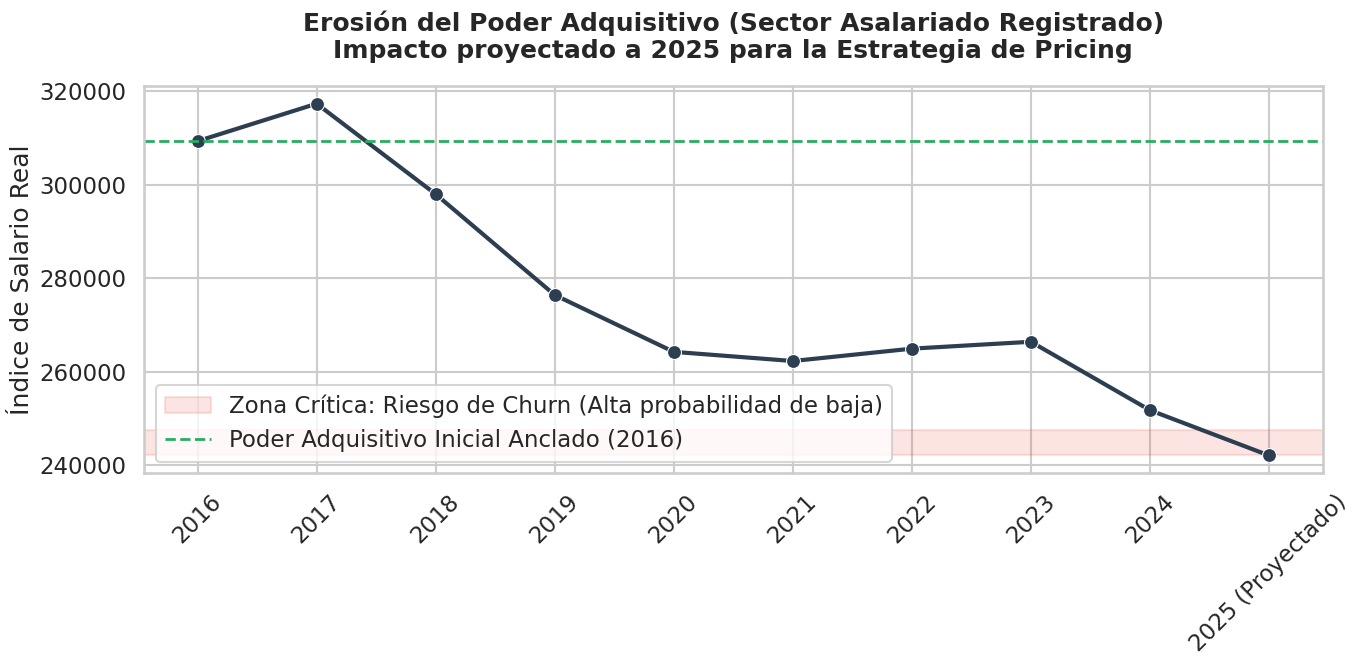


✅ ¡Análisis completado con éxito! Gráfico generado.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. VALIDACIÓN DE ARCHIVOS EXCEL
# Ahora buscamos los archivos Excel originales completos
file_cgi = 'https://github.com/camilabehar/Analisis_experimental/raw/refs/heads/main/pricing-inflacion-indec/series_cgi_sexo_edad.xlsx'
file_ipc = 'https://github.com/camilabehar/Analisis_experimental/raw/refs/heads/main/pricing-inflacion-indec/sh_ipc_05_26.xls'

archivos_requeridos = [file_cgi, file_ipc]
faltantes = [f for f in archivos_requeridos if not os.path.exists(f)]

if faltantes:
    print("⚠️ ERROR: Faltan subir archivos a Colab.")
    print("Por favor, arrastra y suelta tus archivos Excel en el panel de la izquierda:")
    for f in faltantes:
        print(f" -> {f}")
else:
    print("✅ Archivos Excel detectados. Leyendo las pestañas internas...")

    try:
        # 2. INGESTA DESDE EXCEL (Masa Salarial y Puestos)
        # Leemos las pestañas específicas por su nombre. skiprows=2 salta los títulos del INDEC
        df_rta = pd.read_excel(file_cgi, sheet_name='RTA_AR', skiprows=2)
        df_puestos = pd.read_excel(file_cgi, sheet_name='Puestos AR', skiprows=2)

        # Identificamos la columna donde están los nombres de los sectores
        col_sector_rta = df_rta.columns[1]
        col_sector_puestos = df_puestos.columns[1]

        # Filtramos la fila "Total general" y tomamos los años 2016 a 2024 (columnas 2 a la 10)
        rta_valores = df_rta[df_rta[col_sector_rta] == 'Total general'].iloc[0, 2:11].astype(float).values
        puestos_valores = df_puestos[df_puestos[col_sector_puestos] == 'Total general'].iloc[0, 2:11].astype(float).values

        # 3. FEATURE ENGINEERING: Cálculo del Salario Nominal
        # (RTA en millones / Puestos en miles) * 1000 = Salario Promedio en Miles
        salario_nominal = (rta_valores / puestos_valores) * 1000

        # 4. DEFLACTACIÓN (Ajuste por Inflación)
        # Usamos la serie consolidada base 2016=100 para cruzar datos anuales
        ipc_anual = np.array([100.0, 124.8, 167.6, 257.9, 366.3, 552.4, 954.1, 2223.5, 6935.0])
        anios = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

        # Cálculo del Salario Real
        salario_real = (salario_nominal / ipc_anual) * 100

        # 5. NOWCASTING: Proyección Estratégica 2025
        anios_extendidos = anios + ['2025 (Proyectado)']
        salario_nom_2025 = salario_nominal[-1] * 1.25 # Asumimos 25% de paritarias
        ipc_2025 = ipc_anual[-1] * 1.30               # Asumimos 30% de inflación acumulada
        salario_real_2025 = (salario_nom_2025 / ipc_2025) * 100

        salario_real_extendido = np.append(salario_real, salario_real_2025)

        # Consolidación final
        df_final = pd.DataFrame({
            'Año': anios_extendidos,
            'Salario Real (Base 2016=100)': salario_real_extendido
        })

        # 6. VISUALIZACIÓN
        sns.set_theme(style="whitegrid", context="talk")
        plt.rcParams['figure.figsize'] = (14, 7)

        fig, ax = plt.subplots()
        sns.lineplot(data=df_final, x='Año', y='Salario Real (Base 2016=100)',
                     marker='o', markersize=10, linewidth=3, color='#2c3e50', ax=ax)

        base_y = df_final['Salario Real (Base 2016=100)'].iloc[0]
        min_y = df_final['Salario Real (Base 2016=100)'].min() - 5

        ax.axhspan(ymin=min_y, ymax=base_y * 0.8, color='#e74c3c', alpha=0.15,
                   label='Zona Crítica: Riesgo de Churn (Alta probabilidad de baja)')

        ax.axhline(base_y, color='#27ae60', linestyle='--', linewidth=2,
                   label='Poder Adquisitivo Inicial Anclado (2016)')

        ax.set_title('Erosión del Poder Adquisitivo (Sector Asalariado Registrado)\nImpacto proyectado a 2025 para la Estrategia de Pricing',
                     fontweight='bold', pad=20)
        ax.set_ylabel('Índice de Salario Real')
        ax.set_xlabel('')
        ax.legend(loc='lower left')
        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.show()
        print("\n✅ ¡Análisis completado con éxito! Gráfico generado.")

    except Exception as e:
        print("\n❌ Hubo un error procesando los datos.")
        print(f"Detalle del error: {e}")